# Hands-on: Feature Extraction and Clustering

This notebook uses the prepared workshop dataset in based on the Severstal dataset. It is self-contained: no external Severstal path is required during the workshop.

## Context

The theory notebook showed that a pretrained backbone turns an image into a feature vector, and that "normal" images should occupy their own region of that feature space while defects tend to land elsewhere. This notebook is where you check whether that claim actually holds on real steel images, before trusting it inside PatchCore.

Concretely, you will:

1. Turn a few hundred real images into feature vectors with a pretrained backbone (no training involved, the backbone's weights never change here).
2. Compress those vectors down to 2 dimensions with two different techniques (PCA and t-SNE) so they can be plotted and eyeballed.
3. Ask, visually and then quantitatively, whether normal and defect images actually separate in that space.
4. Repeat the whole thing with a different backbone, and compare.

One deliberate simplification: this notebook uses one embedding **per whole image** (like the left side of Figure 5 in the theory notebook). PatchCore, in the next notebook, instead keeps a whole grid of **local patch** embeddings per image. Whole-image embeddings are enough to sanity-check "does this backbone see a difference between normal and defective steel at all?",  but they can hide a small local defect inside one big averaged vector, which is exactly why PatchCore does not stop here.


In [15]:
# This code sets up the module root and dataset paths for the anomaly detection workshop.
# It also configures model caching for PyTorch and Hugging Face to avoid repeated downloads of pretrained models.

import os
from pathlib import Path

MODULE_ROOT = Path(f"/projappl/project_465002387/DEEP_Inspection_Material_Science/users/{os.environ['USER']}")
DATASET_ROOT =  Path(r'/projappl/project_465002387/DEEP_Inspection_Material_Science/data') / 'dataset_anomaly'

MODEL_CACHE = MODULE_ROOT / '_model_cache'
MODEL_CACHE.mkdir(parents=True, exist_ok=True)

os.environ.setdefault('TORCH_HOME', str(MODEL_CACHE / 'torch'))
os.environ.setdefault('HF_HOME', str(MODEL_CACHE / 'huggingface'))
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')

print('Module root:', MODULE_ROOT)
print('Dataset root:', DATASET_ROOT)
print('Model cache:', MODEL_CACHE)


Module root: /projappl/project_465002387/DEEP_Inspection_Material_Science/users/saeedima
Dataset root: /projappl/project_465002387/DEEP_Inspection_Material_Science/data/dataset_anomaly
Model cache: /projappl/project_465002387/DEEP_Inspection_Material_Science/users/saeedima/_model_cache


In [2]:
# This code cell imports all the libraries used in the workshop.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


/opt/venv/lib/python3.12/site-packages/apex/transformer/functional/fused_rope.py:54: UserWarning: Using the native apex kernel for RoPE.
  warnings.warn("Using the native apex kernel for RoPE.", UserWarning)


## 1. Load Prepared Metadata

We have already adapted the Severstal dataset to the anomaly detection task, decided which images count as "normal" vs "defect", and copied a subset into `dataset/anomaly/`. `metadata.csv` is the index into that work, one row per image, with its label, defect class, and file path.


In [3]:
metadata = pd.read_csv(DATASET_ROOT / 'metadata.csv')
metadata['path'] = metadata['relative_path'].apply(lambda p: DATASET_ROOT / p)
display(metadata.head())
metadata.groupby(['workshop_split', 'label']).size()


,workshop_split,label,defect_class,num_objects,image_name,relative_path,source_split,path
0,train/normal,normal,normal,0,981a45fda.jpg,anomaly/train/normal/981a45fda.jpg,train,/projappl/project_465002387/DEEP_Inspection_Ma...
1,train/normal,normal,normal,0,eb082ef3e.jpg,anomaly/train/normal/eb082ef3e.jpg,train,/projappl/project_465002387/DEEP_Inspection_Ma...
2,train/normal,normal,normal,0,e387ce326.jpg,anomaly/train/normal/e387ce326.jpg,train,/projappl/project_465002387/DEEP_Inspection_Ma...
3,train/normal,normal,normal,0,735a876fb.jpg,anomaly/train/normal/735a876fb.jpg,train,/projappl/project_465002387/DEEP_Inspection_Ma...
4,train/normal,normal,normal,0,86f6cc389.jpg,anomaly/train/normal/86f6cc389.jpg,train,/projappl/project_465002387/DEEP_Inspection_Ma...


workshop_split  label 
test/defect     defect    400
test/normal     normal    200
train/normal    normal    600
dtype: int64

The table above should show three groups: `train/normal` (normal images used later to build PatchCore's memory bank), `test/normal` (held-out normal images), and `test/defect`. This notebook does not care about that train/test split at all -- it pools every image together to look at the feature space as a whole. The split only starts to matter in the next notebook, where PatchCore is only allowed to learn from `train/normal`.


In [4]:
# This code cell counts the number of images per defect class in the dataset.

metadata[metadata['label'] == 'defect']['defect_class'].value_counts().head(12)


defect_class
defect_3                      119
defect_1                       53
defect_4                       46
defect_2                       45
defect_3+defect_4              44
defect_1+defect_3              41
defect_1+defect_2              35
defect_2+defect_3              14
defect_1+defect_2+defect_3      2
defect_2+defect_4               1
Name: count, dtype: int64

Real defect labels are rarely single, clean categories. Some images have more than one defect type marked (`defect_1+defect_3`, for example) because two different flaws happened to appear on the same strip.


## 2. Visualize the Data

Before extracting a single feature vector, look at the actual images. This step catches an entire category of mistakes that no amount of clever modeling will fix later: a mislabeled folder, a corrupted image, or defects that turn out to be invisible at the resolution you plan to use. It costs one cell and a few seconds; skipping it costs a debugging session much later when PCA "mysteriously" shows no separation.

Note that this notebook mixes normal and defect images together purely to look at the feature space -- the model being trained here is nothing but "eyeballing a scatter plot." PatchCore, in contrast, is only ever allowed to *train* on normal images; defect images stay strictly in the evaluation role.


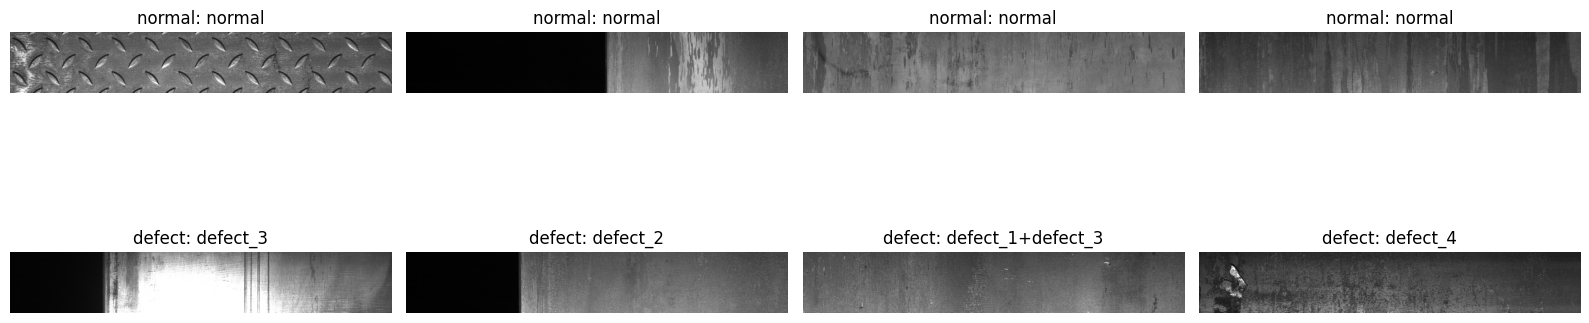

In [5]:
# This code cell samples a few images from the dataset and displays them in a grid.
# It samples from defect and good images, and shows their labels and defect classes.

samples = pd.concat([
    metadata[metadata['workshop_split'] == 'train/normal'].sample(4, random_state=0),
    metadata[metadata['workshop_split'] == 'test/defect'].sample(4, random_state=1),
])

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, (_, row) in zip(axes.ravel(), samples.iterrows()):
    ax.imshow(Image.open(row.path).convert('RGB'))
    ax.set_title(f"{row.label}: {row.defect_class}")
    ax.axis('off')
plt.tight_layout()


Look closely at the top row (normal) versus the bottom row (defect). Some defects are visually obvious even at a glance -- bright scratches, dark inclusions. Others are subtle: a faint texture change that is easy to miss unless you know to look for it. Keep that contrast in mind; it will show up again later as a difference in how cleanly normal and defect images separate in the embedding plots.


## 3. Build a Small Balanced Subset

Extracting an embedding for every image in `dataset/` would work, but PCA is cheap while t-SNE is not: it has to reason about pairwise relationships between every pair of points, so its cost grows quickly with the number of points. Working with a smaller, balanced subset first keeps each experiment in this notebook to a few seconds, which matters when you are about to re-run the same cells for three different backbones later.

"Balanced" here specifically means equal numbers of normal and defect images. If defects were rare in the subset (as they legitimately are in the full dataset), a plot showing "defects mostly land in one corner" could just be five stray points, not a real pattern. Equal group sizes make the visual comparison fair.


In [6]:
N_NORMAL = 120
N_DEFECT = 120

normal_df = metadata[metadata['label'] == 'normal'].sample(N_NORMAL, random_state=2)
defect_df = metadata[metadata['label'] == 'defect'].sample(N_DEFECT, random_state=3)
work_df = pd.concat([normal_df, defect_df], ignore_index=True).sample(frac=1, random_state=4).reset_index(drop=True)

work_df.groupby(['label', 'defect_class']).size().sort_values(ascending=False).head(10)


label   defect_class              
normal  normal                        120
defect  defect_3                       39
        defect_1                       16
        defect_3+defect_4              15
        defect_2                       14
        defect_1+defect_3              12
        defect_1+defect_2              10
        defect_4                        9
        defect_2+defect_3               3
        defect_1+defect_2+defect_3      1
dtype: int64

`work_df` is now the frame every later cell in this notebook operates on. Increasing `N_NORMAL`/`N_DEFECT` gives smoother, more trustworthy plots at the cost of slower re-runs, a reasonable thing to try once the rest of the notebook has run successfully without taking too long. Decreasing them makes the notebook run faster, but the plots will be noisier and less trustworthy. The default values are a reasonable compromise for a workshop setting.


## 4. Extract Embeddings

We start with `wide_resnet50_2`, because it is also the main PatchCore baseline. The feature extractor removes the classifier head and returns one image-level vector per image.

If model weights are not cached yet, timm will download them into `_model_cache/`.

### What actually happens, step by step

For every image, the code below does exactly four things:

1. **Resize and normalize** the image to `224x224` and the ImageNet mean/std the backbone was pretrained with -- the backbone only ever saw images preprocessed this way, so test images must match, or the features it produces are meaningless.
2. **Forward pass** the image through the pretrained CNN, stopping before the final classification layer (`num_classes=0` strips that layer off entirely).
3. **Global-average-pool** the last convolutional feature map: whatever the spatial size of that final feature map is (say `7x7`), average every channel across all `49` locations down to a single number, producing one fixed-length vector per image (`global_pool='avg'`).
4. Stack every image's vector into one big `[num_images, num_features]` matrix.

Nothing here is trained or fine-tuned, every weight in the backbone is exactly what it was after ImageNet pretraining. We are only ever asking "what does this frozen, generic vision model already see?", not teaching it anything new about steel.


In [7]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BACKBONE = 'wide_resnet50_2'
IMAGE_SIZE = 224
BATCH_SIZE = 16
PRETRAINED = True

# the transform used to prepare images for the backbone model

transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# class to wrap the dataset for PyTorch DataLoader, providing images and their labels.

class SteelImageDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row.path).convert('RGB')
        return self.transform(image), row.label, row.defect_class, row.relative_path

# This function extracts embeddings from the images in the provided DataFrame using a specified backbone model.

def extract_embeddings(frame, backbone=BACKBONE, pretrained=PRETRAINED):
    dataset = SteelImageDataset(frame, transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    # ViT backbones (e.g. the DINOv2 preset) ship pretrained weights that only match
    # global_pool='token' (cls-token pooling), not 'avg', and are often trained at a
    # native resolution other than IMAGE_SIZE -- dynamic_img_size=True lets them accept
    # our fixed resize instead of asserting on an exact input size.
    is_vit = 'vit' in backbone
    model = timm.create_model(
        backbone,
        pretrained=pretrained,
        num_classes=0,
        global_pool='token' if is_vit else 'avg',
        **({'dynamic_img_size': True} if is_vit else {}),
    )
    model.eval().to(DEVICE)

    vectors, labels, defect_classes, paths = [], [], [], []
    with torch.no_grad():
        for images, batch_labels, batch_classes, batch_paths in loader:
            features = model(images.to(DEVICE))
            vectors.append(features.cpu())
            labels.extend(batch_labels)
            defect_classes.extend(batch_classes)
            paths.extend(batch_paths)
    return torch.cat(vectors).numpy(), np.array(labels), np.array(defect_classes), np.array(paths)

embeddings, labels, defect_classes, paths = extract_embeddings(work_df)
print('Embedding matrix:', embeddings.shape)


model.safetensors:   0%|          | 0.00/276M [00:00<?, ?B/s]

Embedding matrix: (240, 2048)


### What does one of these vectors actually look like?

`embeddings.shape` is `[num_images, num_features]`, for `wide_resnet50_2` that second number is `2048`. It is easy to talk about "a vector in feature space" abstractly without ever looking at one. Let's look at one.


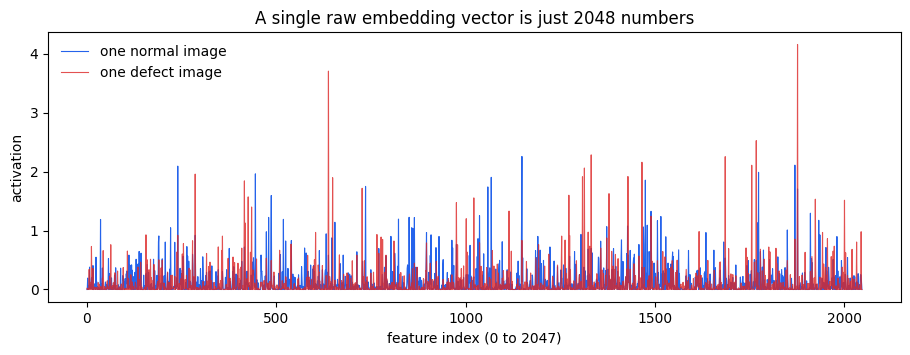

In [8]:
one_normal_idx = np.where(labels == 'normal')[0][0]
one_defect_idx = np.where(labels == 'defect')[0][0]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(embeddings[one_normal_idx], color='#2563eb', lw=0.8, label='one normal image')
ax.plot(embeddings[one_defect_idx], color='#dc2626', lw=0.8, alpha=0.8, label='one defect image')
ax.set_xlabel('feature index (0 to 2047)')
ax.set_ylabel('activation')
ax.set_title('A single raw embedding vector is just 2048 numbers')
ax.legend(frameon=False)
plt.show()


*This is what "a point in 2048-dimensional feature space" means in practice: not a mysterious mathematical object, just an ordinary array of numbers, one per learned feature channel.* No individual spike here is labeled "scratch detector" or "smooth texture detector" -- these are channels the network learned to be useful for classifying a million ImageNet photos, repurposed here simply because they turned out to also carry information about steel surfaces. You are not meant to read meaning into any single spike; the point of PCA and t-SNE below is to summarize the *relationship* between many such vectors, which is far more informative than staring at one.


### What does each layer actually see? (feature maps at different depths)

The embedding above is the *final* pooled vector -- everything the backbone computed on the way there gets averaged away into one number per channel. Before compressing further with PCA and t-SNE, it's worth pausing to look at what the backbone actually produced at each depth along the way, on a real defect image.

We will generate a feature map for each of the four main stages of the backbone. Each channel is a 2D array of numbers, which we can treat as a grayscale image. The deeper the stage, the more abstract the features become, and the smaller the spatial resolution gets.

- Act 1: The first stage of the backbone sees the image at full resolution, and its channels are mostly edge detectors and color blobs. The defect is visible, but not yet highlighted.
- From there on, each stage sees a progressively smaller spatial resolution, but the channels become more abstract and semantically meaningful. By the final stage, the defect is clearly highlighted in some channels, while others ignore it entirely. The global average pooling then compresses all of this into one vector per image, which is what we will analyze with PCA and t-SNE next.

In [9]:
layer_sample_row = work_df[work_df['label'] == 'defect'].iloc[0]
layer_sample_image = Image.open(layer_sample_row.path).convert('RGB')
layer_sample_tensor = transform(layer_sample_image).unsqueeze(0).to(DEVICE)

depth_model = timm.create_model(BACKBONE, features_only=True, pretrained=True)
depth_model.eval().to(DEVICE)

with torch.no_grad():
    depth_feature_maps = depth_model(layer_sample_tensor)

for name, feature_map in zip(depth_model.feature_info.module_name(), depth_feature_maps):
    print(f'{name}: {tuple(feature_map.shape)}')

act1: (1, 64, 112, 112)
layer1: (1, 256, 56, 56)
layer2: (1, 512, 28, 28)
layer3: (1, 1024, 14, 14)
layer4: (1, 2048, 7, 7)


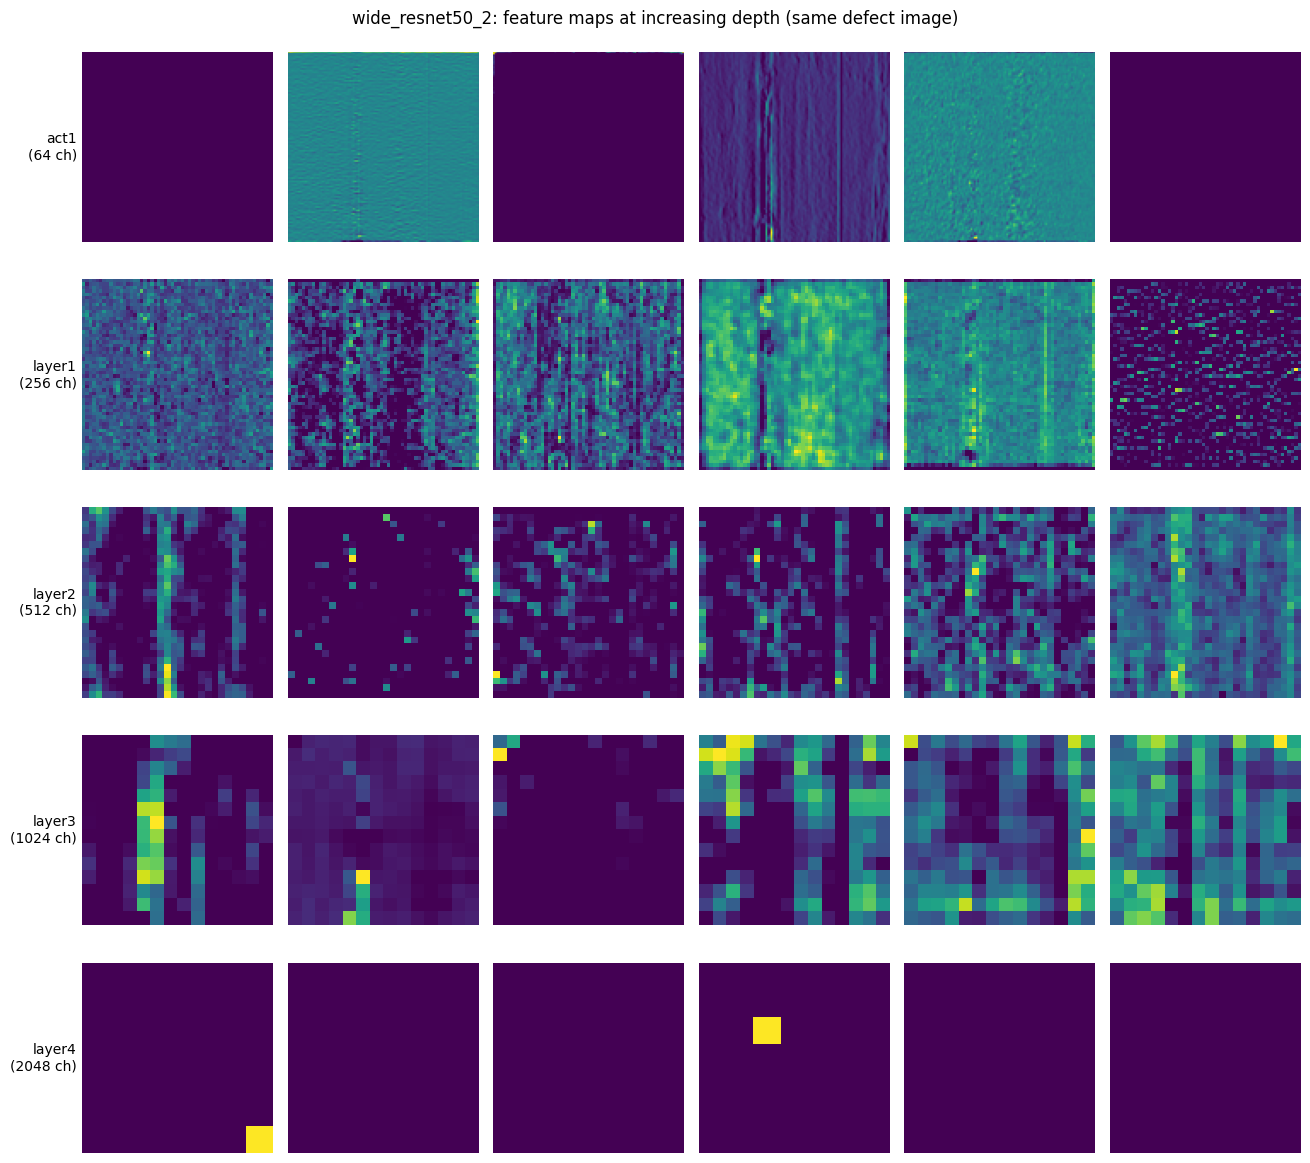

In [10]:
N_SHOW = 6
layer_names = depth_model.feature_info.module_name()

fig, axes = plt.subplots(len(depth_feature_maps), N_SHOW, figsize=(2.2 * N_SHOW, 2.4 * len(depth_feature_maps)))
for row, (name, feature_map) in enumerate(zip(layer_names, depth_feature_maps)):
    channels = feature_map[0].cpu()
    for col in range(N_SHOW):
        ax = axes[row, col]
        if col < channels.shape[0]:
            channel = channels[col].numpy()
            channel = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
            ax.imshow(channel, cmap='viridis')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[row, 0].set_ylabel(f'{name}\n({channels.shape[0]} ch)', rotation=0, ha='right', va='center', fontsize=10)

plt.suptitle(f'{BACKBONE}: feature maps at increasing depth (same defect image)')
plt.tight_layout()
plt.show()

Each column above is one channel of the feature map at that stage. The first row is the raw image, and the last row is the final pooled vector (reshaped to a square for display). What is a channel in this context? It is a learned filter that responds to some visual pattern in the input image. The first stage's channels are mostly edge detectors and color blobs, while the last stage's channels are more abstract, responding to larger-scale structures.

Notice the progression: the earliest stage's feature maps look close to the raw image -- edges, contrast, fine texture. By the last stage, the maps are coarse (much lower resolution) and increasingly abstract, more about "is there some large-scale structure here" than about fine surface texture. 

It might seem counterintuitive that the yellow blobs in the last layer are not necessarily aligned with the defect, but that is exactly the point: the backbone has learned to detect patterns that are useful for ImageNet classification, not steel defect detection. Some of those patterns happen to correlate with defects, while others do not. The global average pooling then compresses all of this into one vector per image, which is what we will analyze with PCA and t-SNE next.

This is exactly why the Anomalib hands-on notebook's PatchCore presets default to `layer2` and `layer3` specifically -- the two middle rows above, rather than the first or last stage: enough spatial resolution left to localize a small defect precisely, but with enough learned structure to be a genuinely discriminative descriptor rather than near-raw pixels.

## 5. PCA

2048 dimensions cannot be plotted directly, so we need to compress each vector down to 2 numbers we *can* plot on an x/y grid. PCA (Principal Component Analysis) does this by finding the two orthogonal directions in the 2048-dimensional space along which the data varies the most, and projecting every point onto just those two directions, like photographing a 3D object from the one angle that reveals the most about its shape, except here we are choosing the best 2 axes out of 2048.

We standardize first (`StandardScaler`, zero mean and unit variance per feature) so that PCA's notion of "most variation" is not dominated by a handful of feature channels that simply happen to have larger raw numeric ranges than the rest. Without this step, PCA can end up describing scale differences between channels rather than real structure in the data.

In the code below, `pca_embeddings` is the `[num_images, 2]` matrix of PCA-compressed vectors, and `pca.explained_variance_ratio_` tells us how much of the original 2048-dimensional variance is captured by those two axes. The higher that number, the more faithfully the 2D plot represents the original data. The PCA function is deterministic, so re-running the cell will always produce the same plot. It is implemented in `sklearn.decomposition.PCA` and is very fast, so you can try increasing `N_NORMAL`/`N_DEFECT` to see how the plot changes with more data. PCA is a linear method, so it cannot capture complex nonlinear relationships in the data, but it is fast and often good enough to reveal the main structure of the feature space.


Variance explained by these 2 components: 16.9% of the original 2048 dimensions


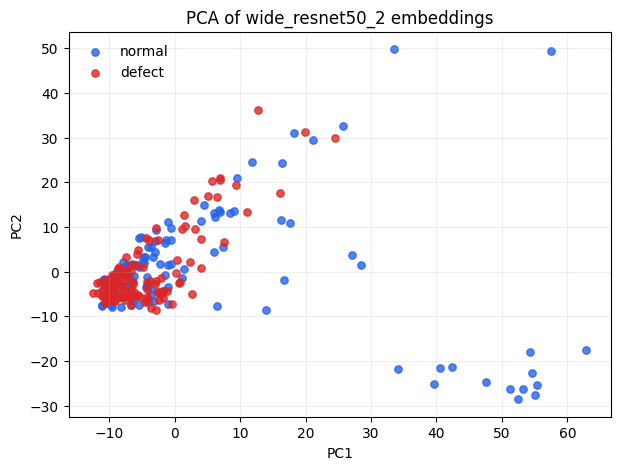

In [11]:
scaled = StandardScaler().fit_transform(embeddings)
pca = PCA(n_components=2, random_state=0)
pca_xy = pca.fit_transform(scaled)
print(f'Variance explained by these 2 components: {pca.explained_variance_ratio_.sum():.1%} of the original 2048 dimensions')

fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [('normal', '#2563eb'), ('defect', '#dc2626')]:
    mask = labels == label
    ax.scatter(pca_xy[mask, 0], pca_xy[mask, 1], s=28, alpha=0.8, label=label, color=color)
ax.set_title(f'PCA of {BACKBONE} embeddings')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()


That printed percentage matters for interpreting the plot honestly: it is normal for 2 components out of 2048 to explain only a modest slice of the total variance. If normal and defect points visibly separate even in that small slice, the *true* separation in the full 2048-dimensional space is likely at least as strong. But if they overlap here, that alone does not prove they are inseparable. It may simply mean the separating signal lives in a direction PCA did not prioritize (PCA optimizes for variance, not for separating your two labeled groups; it never even looks at the `label` column).


## 6. t-SNE

PCA is intentionally simple: it only ever draws straight lines through feature space. t-SNE takes a different, nonlinear approach: rather than maximizing total variance, it tries to keep points that were close together in the original 2048-dimensional space close together in the 2D plot, and let distant points fall wherever -- prioritizing *local neighborhoods* over global geometry. This often teases apart clusters that PCA's straight-line projection blends together.

The trade-off: t-SNE's layout is easy to over-interpret. Two rules worth keeping in mind while looking at the plot below:

- **Distances between separated clusters are not meaningful.** t-SNE does not promise that a cluster twice as far away is "twice as different", only relative closeness within a neighborhood is preserved.
- **Cluster sizes are not meaningful either.** t-SNE can make a tight, homogeneous group of points look artificially spread out, or a diverse group look artificially compact.

`TSNE_PERPLEXITY` roughly controls how many neighbors each point balances against (think of it as a soft "how many nearby points count as a neighborhood"). Try lowering or raising it and rerunning to see how much the layout changes. If the *general story* (whether normal and defect separate) changes drastically with perplexity, that is itself a sign the separation is not very robust.


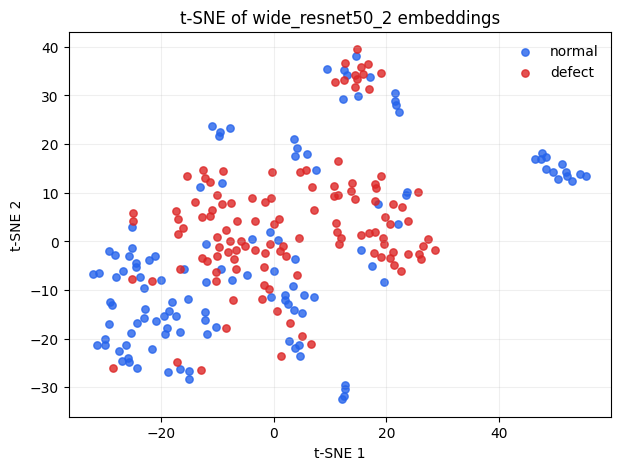

In [12]:
TSNE_PERPLEXITY = 10
TSNE_LEARNING_RATE = 'auto'

tsne_xy = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, init='pca', learning_rate=TSNE_LEARNING_RATE, random_state=0).fit_transform(scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [('normal', '#2563eb'), ('defect', '#dc2626')]:
    mask = labels == label
    ax.scatter(tsne_xy[mask, 0], tsne_xy[mask, 1], s=28, alpha=0.8, label=label, color=color)
ax.set_title(f't-SNE of {BACKBONE} embeddings')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()


## Assignment: Compare Backbones

`extract_embeddings()` already accepts a `backbone` argument, so comparing backbones is one function call away. Running the cell below extracts embeddings with each backbone in `BACKBONES_TO_COMPARE` and scores how well each one separates normal from defect images.

`silhouette_score` measures cluster separation in the *scaled* embedding space (higher is more separated, range -1 to 1). It won't perfectly predict the PatchCore results in the next notebook — this notebook uses whole-image features, PatchCore uses local patch features — but a backbone that struggles to separate normal from defect here is a warning sign worth discussing.


In [13]:
BACKBONES_TO_COMPARE = ['resnet18', 'wide_resnet50_2', 'vit_small_patch14_dinov2.lvd142m']
COMPARISON_TSNE_PERPLEXITY = 30  # try lowering/raising this and rerunning to see how the t-SNE plots below change

backbone_results = {}
for backbone_name in BACKBONES_TO_COMPARE:
    print(f'--- Extracting embeddings with {backbone_name} ---')
    emb, lab, cls, pth = extract_embeddings(work_df, backbone=backbone_name)
    scaled_emb = StandardScaler().fit_transform(emb)
    score = silhouette_score(scaled_emb, lab)
    pca_emb = PCA(n_components=2, random_state=0).fit_transform(scaled_emb)
    tsne_emb = TSNE(n_components=2, perplexity=COMPARISON_TSNE_PERPLEXITY, init='pca', learning_rate='auto', random_state=0).fit_transform(scaled_emb)
    backbone_results[backbone_name] = {'labels': lab, 'silhouette': score, 'pca_xy': pca_emb, 'tsne_xy': tsne_emb}
    print(f'{backbone_name}: silhouette score (normal vs defect) = {score:.3f}')

--- Extracting embeddings with resnet18 ---


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

resnet18: silhouette score (normal vs defect) = 0.023
--- Extracting embeddings with wide_resnet50_2 ---
wide_resnet50_2: silhouette score (normal vs defect) = 0.021
--- Extracting embeddings with vit_small_patch14_dinov2.lvd142m ---


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

vit_small_patch14_dinov2.lvd142m: silhouette score (normal vs defect) = 0.042


,backbone,silhouette_score
0,vit_small_patch14_dinov2.lvd142m,0.041980
1,resnet18,0.022629
2,wide_resnet50_2,0.020932


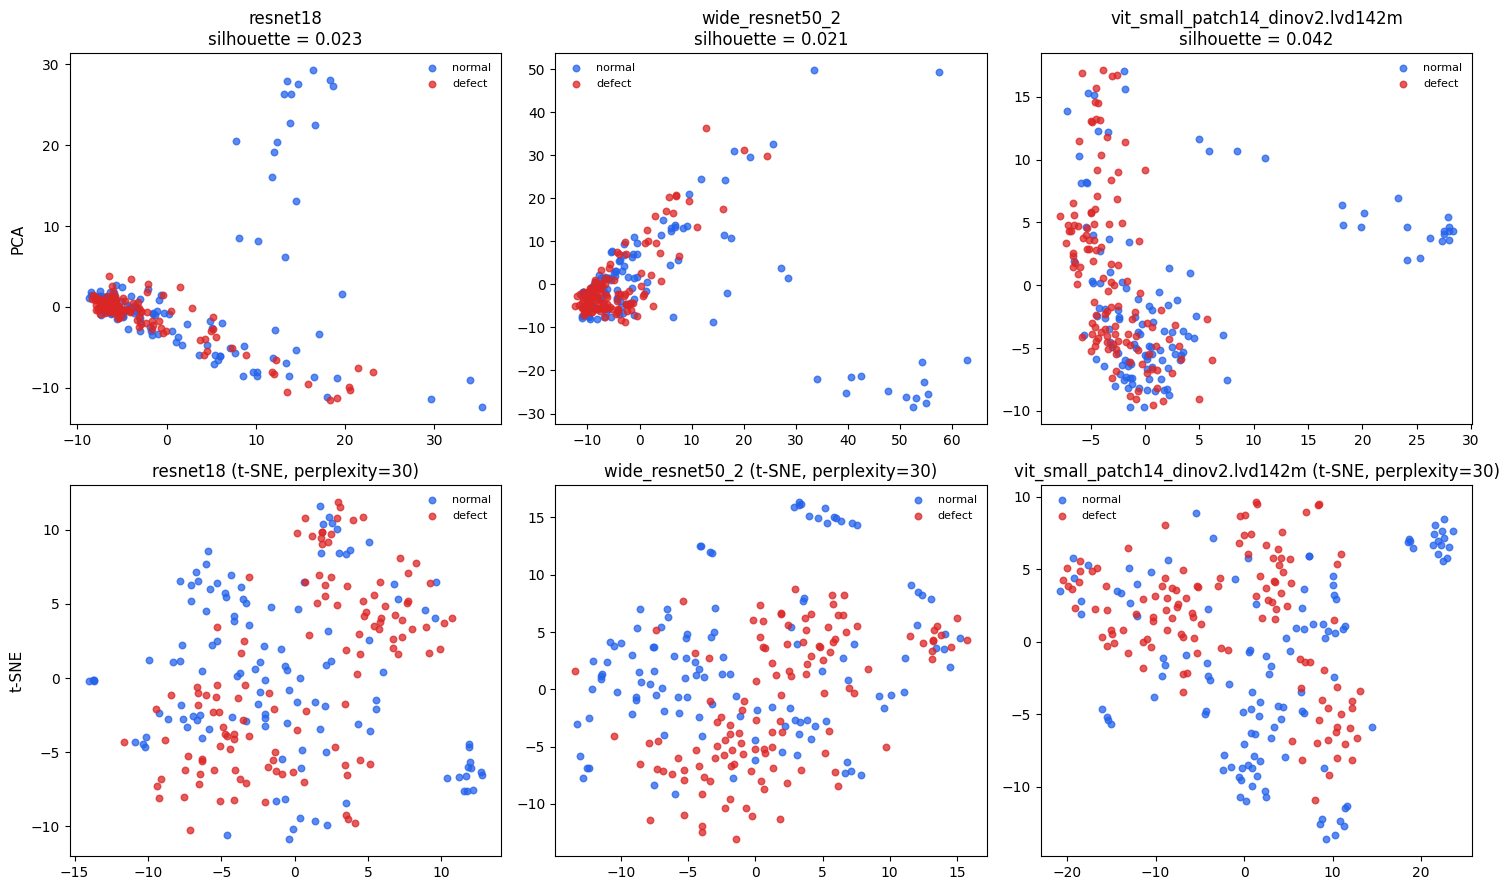

In [14]:
comparison_df = pd.DataFrame(
    [{'backbone': name, 'silhouette_score': res['silhouette']} for name, res in backbone_results.items()]
).sort_values('silhouette_score', ascending=False).reset_index(drop=True)
display(comparison_df)

fig, axes = plt.subplots(2, len(backbone_results), figsize=(5 * len(backbone_results), 9))
for col, (name, res) in enumerate(backbone_results.items()):
    for label, color in [('normal', '#2563eb'), ('defect', '#dc2626')]:
        mask = res['labels'] == label
        axes[0, col].scatter(res['pca_xy'][mask, 0], res['pca_xy'][mask, 1], s=22, alpha=0.75, label=label, color=color)
        axes[1, col].scatter(res['tsne_xy'][mask, 0], res['tsne_xy'][mask, 1], s=22, alpha=0.75, label=label, color=color)
    axes[0, col].set_title(f"{name}\nsilhouette = {res['silhouette']:.3f}")
    axes[0, col].legend(frameon=False, fontsize=8)
    axes[1, col].set_title(f'{name} (t-SNE, perplexity={COMPARISON_TSNE_PERPLEXITY})')
    axes[1, col].legend(frameon=False, fontsize=8)
axes[0, 0].set_ylabel('PCA', fontsize=11)
axes[1, 0].set_ylabel('t-SNE', fontsize=11)
plt.tight_layout()
plt.show()

Discuss: which backbone separates normal from defect best by this measure? Does a bigger or more modern backbone always win? Keep this table in mind when you compare the same three backbones as PatchCore presets in the next notebook — do the rankings agree?
